In [1]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# read the pickle file
with open('../tracker_stubs/ball_detections.pkl', 'rb') as f:
    ball_positions = pickle.load(f)

In [3]:
ball_positions = [x.get(1,[]) for x in ball_positions]
# convert the list into pandas dataframe
df_ball_positions = pd.DataFrame(ball_positions,columns=['x1','y1','x2','y2'])

# interpolate the missing values
df_ball_positions = df_ball_positions.interpolate()
df_ball_positions = df_ball_positions.bfill()

In [4]:
df_ball_positions['mid_y'] = (df_ball_positions['y1'] + df_ball_positions['y2'])/2
df_ball_positions['mid_y_rolling_mean'] = df_ball_positions['mid_y'].rolling(window=5, min_periods=1, center=False).mean()

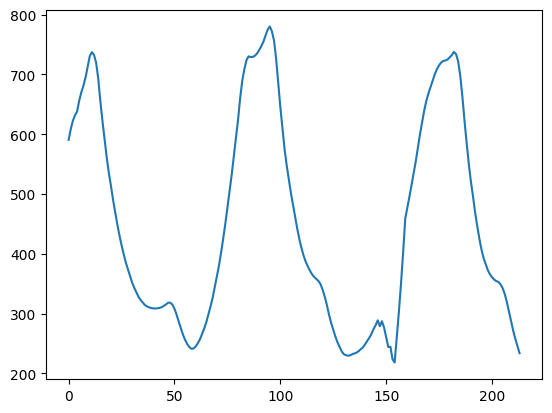

In [5]:
# plot mid_y_rolling_mean
plt.plot(df_ball_positions['mid_y_rolling_mean'])

In [6]:
df_ball_positions['delta_y'] = df_ball_positions['mid_y_rolling_mean'].diff()

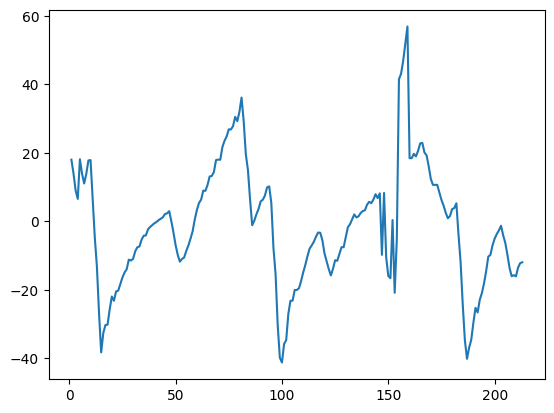

In [7]:
# plot mid_y_rolling_mean
plt.plot(df_ball_positions['delta_y'])

In [8]:
df_ball_positions['ball_hit']=0

In [9]:
minimum_change_frames_for_hit = 25
for i in range(1,len(df_ball_positions)- int(minimum_change_frames_for_hit*1.2) ):
    negative_position_change = df_ball_positions['delta_y'].iloc[i] >0 and df_ball_positions['delta_y'].iloc[i+1] <0
    positive_position_change = df_ball_positions['delta_y'].iloc[i] <0 and df_ball_positions['delta_y'].iloc[i+1] >0

    if negative_position_change or positive_position_change:
        change_count = 0 
        for change_frame in range(i+1, i+int(minimum_change_frames_for_hit*1.2)+1):
            # Check if the direction change persists (same sign as frame i+1)
            if negative_position_change and df_ball_positions['delta_y'].iloc[change_frame] < 0:
                change_count += 1
            elif positive_position_change and df_ball_positions['delta_y'].iloc[change_frame] > 0:
                change_count += 1
    
        if change_count > minimum_change_frames_for_hit - 1:
            df_ball_positions['ball_hit'].iloc[i] = 1

frame_nums_with_ball_hits = df_ball_positions[df_ball_positions['ball_hit']==1].index.tolist()

In [10]:
df_ball_positions[df_ball_positions['ball_hit']==1]

,x1,y1,x2,y2,mid_y,mid_y_rolling_mean,delta_y,ball_hit
11,779.258789,719.740723,794.413696,736.431335,728.086029,737.092920,6.351874,1
58,923.938293,236.003510,940.278259,248.384872,242.194191,241.086740,-2.914380,1
95,616.406677,769.795715,641.092407,797.075134,783.435425,780.033545,5.353644,1
147,602.747314,215.258347,614.562378,228.839005,222.048676,278.876230,-9.796091,1
151,585.096191,215.640884,601.260376,233.575470,224.608177,244.068849,-16.642650,1
154,619.803223,204.680923,636.051086,217.139282,210.910103,218.210835,-5.365192,1
182,1294.516724,738.925781,1316.180054,761.516235,750.221008,737.531909,5.284302,1
